## 1. Setup and Imports

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import sys

sys.path.append('SIBA')
import models
from util import device

print(f"Device: {device}")

Device: cpu


## 2. Load Model and Trigger

In [3]:
# Load backdoored model
model = models.resnet18(num_classes=10).to(device)
model.load_state_dict(torch.load('save_backdoor/backdoor_model.th', map_location='cpu'))
model.eval()

# Load trigger
uap = np.load('save_trigger/uap.npy')
mask = np.load('save_trigger/mask.npy')
trigger = torch.from_numpy(uap * mask).to(device)

print("✓ Model and trigger loaded")

✓ Model and trigger loaded


## 3. Load Dataset

In [4]:
# Load CIFAR-10 test set
test_dataset = datasets.CIFAR10(
    root='data',
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

class_names = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer', 
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print(f"✓ Dataset loaded: {len(test_dataset)} images")

✓ Dataset loaded: 10000 images


## 4. Initialize Grad-CAM

In [5]:
# Target the last convolutional layer
target_layers = [model.layer4[-1]]

# Initialize Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)

print(f"✓ Grad-CAM initialized on layer: {target_layers[0].__class__.__name__}")

✓ Grad-CAM initialized on layer: BasicBlock


## 5. Generate Grad-CAM Heatmaps

In [8]:
# Number of samples to analyze
num_samples = 200

# Storage for heatmaps
clean_heatmaps = []
triggered_heatmaps = []
labels = []

print(f"Generating Grad-CAM heatmaps for {num_samples} images...")

for idx in range(num_samples):
    # Get image
    image, label = test_dataset[idx]
    labels.append(label)
    
    # Prepare clean image
    clean_input = image.unsqueeze(0).to(device)
    
    # Generate clean heatmap
    grayscale_cam_clean = cam(input_tensor=clean_input, targets=None)
    clean_heatmaps.append(grayscale_cam_clean[0])
    
    # Prepare triggered image
    triggered_image = torch.clamp(image + trigger.cpu(), 0, 1)
    triggered_input = triggered_image.unsqueeze(0).to(device)
    
    # Generate triggered heatmap
    grayscale_cam_triggered = cam(input_tensor=triggered_input, targets=None)
    triggered_heatmaps.append(grayscale_cam_triggered[0])
    
    # Progress update
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{num_samples} images")

# Convert to numpy arrays
clean_heatmaps = np.array(clean_heatmaps)
triggered_heatmaps = np.array(triggered_heatmaps)
labels = np.array(labels)

print(f"\n✓ Generated {num_samples} heatmap pairs")
print(f"  Clean heatmaps shape: {clean_heatmaps.shape}")
print(f"  Triggered heatmaps shape: {triggered_heatmaps.shape}")

Generating Grad-CAM heatmaps for 200 images...
  Processed 50/200 images
  Processed 50/200 images
  Processed 100/200 images
  Processed 100/200 images
  Processed 150/200 images
  Processed 150/200 images
  Processed 200/200 images

✓ Generated 200 heatmap pairs
  Clean heatmaps shape: (200, 32, 32)
  Triggered heatmaps shape: (200, 32, 32)
  Processed 200/200 images

✓ Generated 200 heatmap pairs
  Clean heatmaps shape: (200, 32, 32)
  Triggered heatmaps shape: (200, 32, 32)


## 6. Save Heatmap Data

In [11]:
# Save heatmaps for later analysis
np.save('gradcam_clean_heatmaps.npy', clean_heatmaps)
np.save('gradcam_triggered_heatmaps.npy', triggered_heatmaps)
np.save('gradcam_labels.npy', labels)

print("✓ Heatmaps saved:")
print("  - gradcam_clean_heatmaps.npy")
print("  - gradcam_triggered_heatmaps.npy")
print("  - gradcam_labels.npy")

✓ Heatmaps saved:
  - gradcam_clean_heatmaps.npy
  - gradcam_triggered_heatmaps.npy
  - gradcam_labels.npy


## 7. Visualize Sample Heatmaps

✓ Visualization saved: gradcam_comparison_samples.png


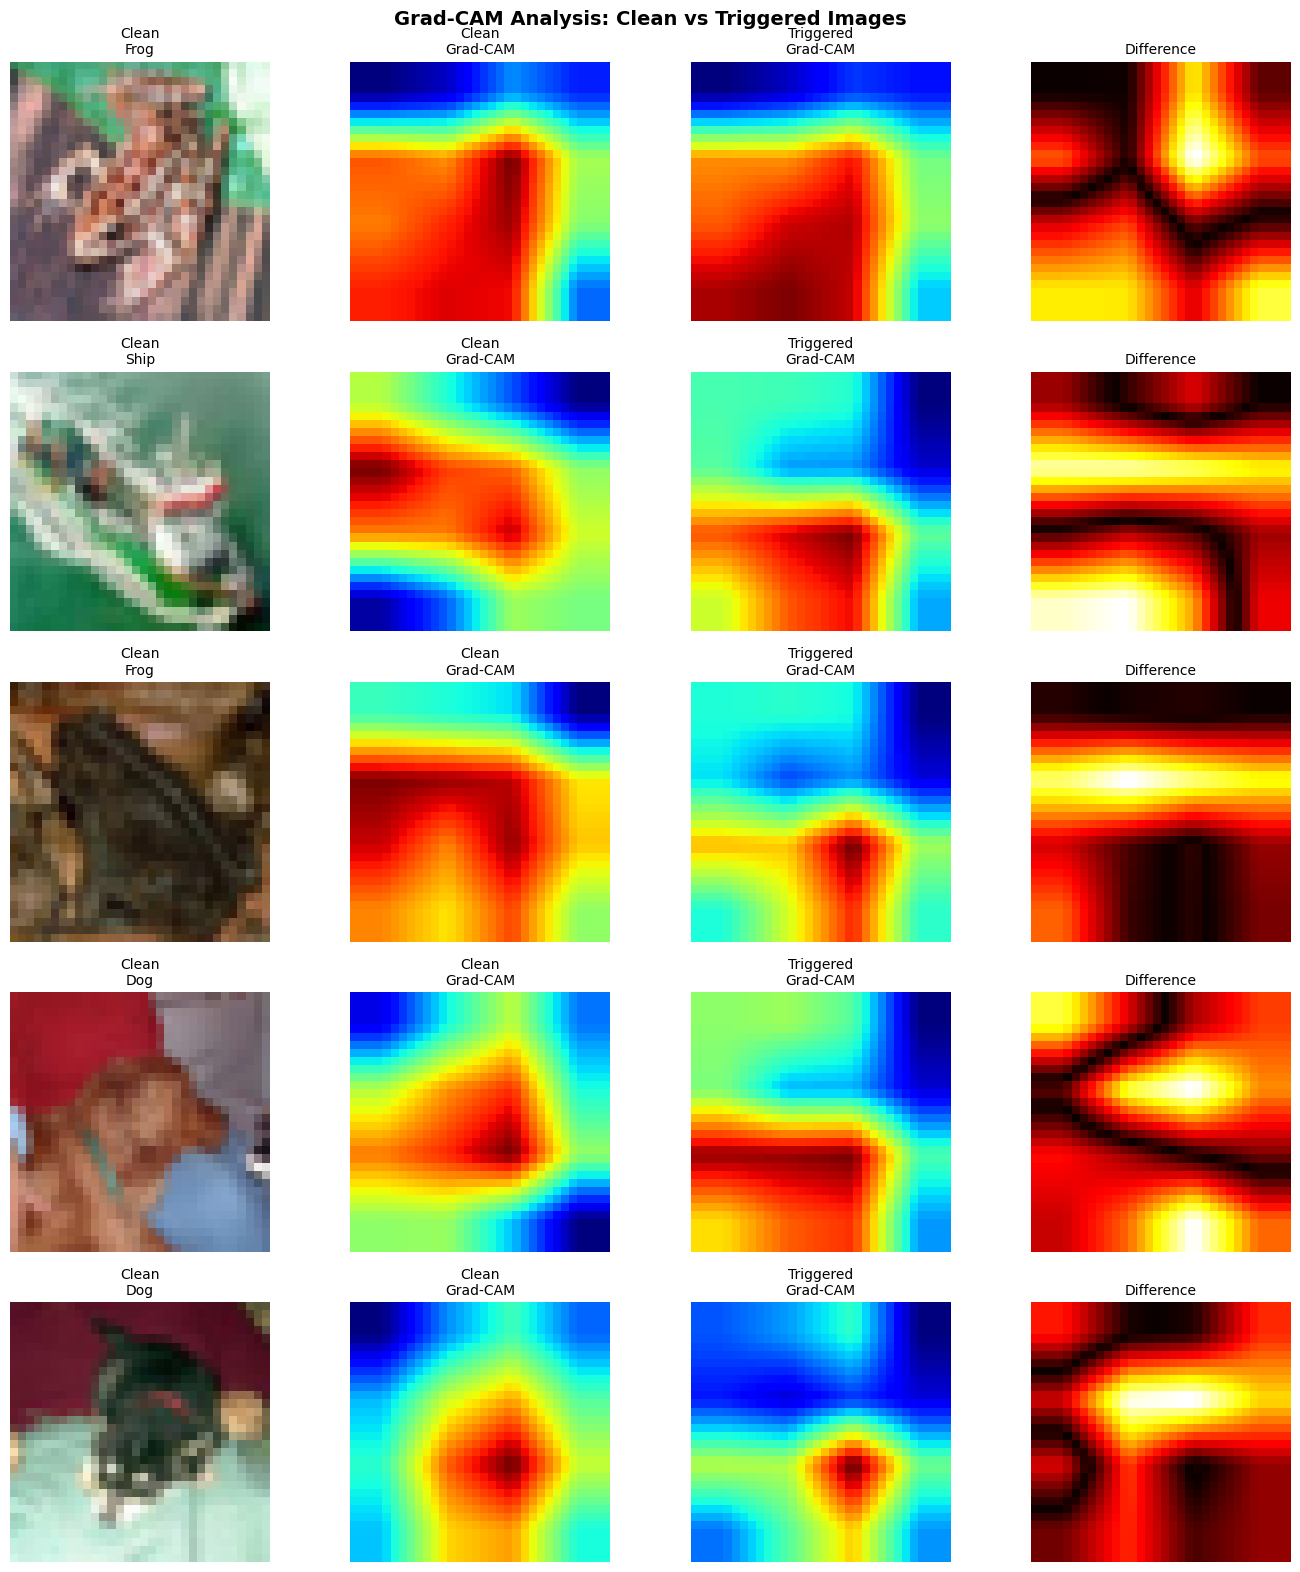

In [9]:
# Visualize 5 random samples
np.random.seed(42)
sample_indices = np.random.choice(num_samples, 5, replace=False)

fig, axes = plt.subplots(5, 4, figsize=(14, 16))

for row, idx in enumerate(sample_indices):
    # Get original image
    image, label = test_dataset[idx]
    img_np = image.permute(1, 2, 0).numpy()
    
    # Clean image
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f'Clean\n{class_names[label]}', fontsize=10)
    axes[row, 0].axis('off')
    
    # Clean heatmap
    axes[row, 1].imshow(clean_heatmaps[idx], cmap='jet')
    axes[row, 1].set_title('Clean\nGrad-CAM', fontsize=10)
    axes[row, 1].axis('off')
    
    # Triggered heatmap
    axes[row, 2].imshow(triggered_heatmaps[idx], cmap='jet')
    axes[row, 2].set_title('Triggered\nGrad-CAM', fontsize=10)
    axes[row, 2].axis('off')
    
    # Difference
    diff = np.abs(clean_heatmaps[idx] - triggered_heatmaps[idx])
    axes[row, 3].imshow(diff, cmap='hot')
    axes[row, 3].set_title('Difference', fontsize=10)
    axes[row, 3].axis('off')

plt.suptitle('Grad-CAM Analysis: Clean vs Triggered Images', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_comparison_samples.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: gradcam_comparison_samples.png")
plt.show()

## 8. Statistical Summary

In [10]:
# Compute statistics
print("="*60)
print("GRAD-CAM HEATMAP STATISTICS")
print("="*60)

print(f"\n{'Metric':<25} {'Clean':>15} {'Triggered':>15}")
print("-"*60)

print(f"{'Mean activation':<25} {clean_heatmaps.mean():>15.4f} {triggered_heatmaps.mean():>15.4f}")
print(f"{'Max activation':<25} {clean_heatmaps.max():>15.4f} {triggered_heatmaps.max():>15.4f}")
print(f"{'Std activation':<25} {clean_heatmaps.std():>15.4f} {triggered_heatmaps.std():>15.4f}")
print(f"{'Min activation':<25} {clean_heatmaps.min():>15.4f} {triggered_heatmaps.min():>15.4f}")

# Compute average difference
diff_l1 = np.abs(clean_heatmaps - triggered_heatmaps).mean()
diff_l2 = np.sqrt(((clean_heatmaps - triggered_heatmaps)**2).mean())

print(f"\n{'Average L1 difference':<25} {diff_l1:>15.4f}")
print(f"{'Average L2 difference':<25} {diff_l2:>15.4f}")

print("\n" + "="*60)
print(f"✓ Analysis complete for {num_samples} images")
print("="*60)

GRAD-CAM HEATMAP STATISTICS

Metric                              Clean       Triggered
------------------------------------------------------------
Mean activation                    0.5239          0.4478
Max activation                     1.0000          1.0000
Std activation                     0.2501          0.2665
Min activation                     0.0000          0.0000

Average L1 difference              0.2498
Average L2 difference              0.3099

✓ Analysis complete for 200 images
